# Demo 10. Atmospheric Blocking

## 1. Prepare input data

Go to ESGF note (https://metagrid.esgf-west.org/search), search for daily zg, and download.

In [10]:
#datadir = "/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/CSIRO/ACCESS-CM2/historical/day/zg"
#datadir = "/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/NCAR-CESM2/amip/day/zg"
#datadir = "/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/GFDL-CM4/historical/day/zg"
datadir = "/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg"

In [11]:
!ls {datadir}/*.nc

/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500101-19500131.nc
/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500201-19500228.nc
/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500301-19500331.nc
/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500401-19500430.nc
/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500501-19500531.nc
/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500601-19500630.nc
/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500701-19500731.nc
/global/cfs/cdirs/m4581/lee1043/wo

## 2. Set parameters

In [12]:
# Define the file content using a multi-line f-string
content = f"""# Path pattern for input height data files
FILE_GLOB = "{datadir}/zg_day_*_*.nc"

# Processing configuration
PRESSURE_LEVEL = 500
START_DATE = "1950-01-01"
#START_DATE = "2014-01-01"
END_DATE = "2014-12-31"

# Output configuration
OUTPUT_DIR = "./demo_output/atmospheric_block"
STITCHED_OUT_NAME = "block_tag.stitched.nc"
CLEANUP_TEMP = True
"""

# Write it to the file
with open("param_atmblock.py", "w") as f:
    f.write(content)

In [13]:
%pycat param_atmblock.py

# Path pattern for input height data files
FILE_GLOB = "/global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_*_*.nc"

# Processing configuration
PRESSURE_LEVEL = 500
START_DATE = "1950-01-01"
#START_DATE = "2014-01-01"
END_DATE = "2014-12-31"

# Output configuration
OUTPUT_DIR = "./demo_output/atmospheric_block"
STITCHED_OUT_NAME = "block_tag.stitched.nc"
CLEANUP_TEMP = True


## 3. Run the code

Need to install [TempestExtremes](https://github.com/ClimateGlobalChange/tempestextremes) (Ullrich et al. 2021) if you are yet to have it in your environment.

Ullrich, P. A., Zarzycki, C. M., McClenny, E. E., Pinheiro, M. C., Stansfield, A. M., and Reed, K. A.: TempestExtremes v2.1: a community framework for feature detection, tracking, and analysis in large datasets, Geosci. Model Dev., 14, 5023–5048, https://doi.org/10.5194/gmd-14-5023-2021, 2021.

In [14]:
"""
!conda install -c conda-forge tempest-extremes
"""

'\n!conda install -c conda-forge tempest-extremes\n'

In [15]:
%%bash
atmospheric_block_driver.py -p param_atmblock.py

Using params from: param_atmblock.py

Output directory: ./demo_output/atmospheric_block/blocking

Created temporary directory: /pscratch/sd/l/lee1043/git/pcmdi_metrics/doc/jupyter/Demo/demo_output/atmospheric_block/blocking/block_processing_6u8iobfw

Processing /global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500101-19500131.nc
Processing /global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500201-19500228.nc
Processing /global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500301-19500331.nc
Processing /global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500401-19500430.nc
Processing /global/cfs/cdirs/m4581/lee1043/work/ESGF/CMIP6/CMIP/E3SM/hist-1950/day/zg/zg_day_CMCC-CM2-HR4_hist-1950_r1i1p1f1_gn_19500501-19500531.nc
Proc

# Test

In [16]:
import xcdat as xc

In [21]:
datafile = '/pscratch/sd/l/lee1043/git/pcmdi_metrics/doc/jupyter/Demo/demo_output/atmospheric_block/blocking/block_id.19502014.nc'

In [22]:
ds = xc.open_dataset(datafile)

In [23]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 23725, latitude: 111, longitude: 288, bnds: 2)
Coordinates:
  * time            (time) object 190kB 1950-01-01 00:00:00 ... 2014-12-31 00...
  * latitude        (latitude) float64 888B 35.34 35.34 36.28 ... 89.06 90.0
  * longitude       (longitude) float64 2kB 0.0 1.25 2.5 ... 356.2 357.5 358.8
Dimensions without coordinates: bnds
Data variables:
    block_id        (time, latitude, longitude) int32 3GB ...
    longitude_bnds  (longitude, bnds) float64 5kB -0.625 0.625 ... 358.1 359.4
    latitude_bnds   (latitude, bnds) float64 2kB 35.34 35.34 ... 89.53 90.0

Install `hvplot` and `jupyter_bokeh` for the following part.

In [24]:
import hvplot.xarray  # This activates the .hvplot accessor on xarray objects
import holoviews as hv

# 1. Initialize the Bokeh backend
hv.extension('bokeh')

# 2. Generate the interactive animation plot
animation = ds['block_id'].hvplot.image(
    x='longitude', 
    y='latitude', 
    groupby='time',
    cmap='viridis',        # Works well for discrete/integer block tags
    widget_type='scrubber',   # Adds a VCR-like play/pause/step button interface
    widget_location='bottom', # Places the animation player below the map
    width=700,
    height=450,
    #rasterize=True            # Keeps rendering fast and memory efficient
)

# Display it in your Jupyter notebook
animation

BokehModel(combine_events=True, render_bundle={'docs_json': {'f06c210d-584b-46f4-879e-b3b553c6bd63': {'version…

In [38]:
ds.block_id.data.max()

np.int32(1851)

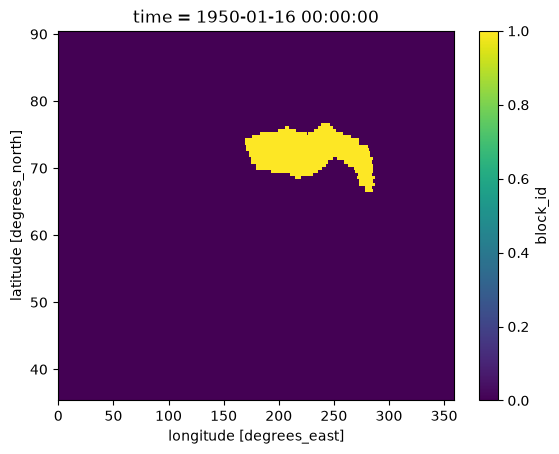

In [ ]:
ds.block_id.isel(time=15).plot()

In [41]:
ds2 = xc.open_mfdataset(f'{datadir}/*.nc')